---
authors:
  - name: Juniper Tyree
    orcid: 0000-0002-7923-9609
    affiliations:
      - name: University of Helsinki
        ror: 040af2s02
    github: juntyr
  - name: Langwen Huang
    orcid: 0000-0002-9204-0346
    affiliations:
      - name: ETH Zurich
        ror: 05a28rw58
    github: huanglangwen
---

# EBCC

| [![version-badge]][version-url] | [![citation-badge]][citation-url] | [![source-badge]][source-url] | [![pitch-badge]][pitch-url] |
|:-:|:-:|:-:|:-:|

[version-badge]: https://img.shields.io/badge/v0.1.5--alpha-grey?style=for-the-badge
[citation-badge]: https://img.shields.io/badge/citation-grey?style=for-the-badge&logo=doi&logoColor=white
[source-badge]: https://img.shields.io/badge/source-grey?style=for-the-badge&logo=github&logoColor=white
[documentation-badge]: https://img.shields.io/badge/documentation-grey?style=for-the-badge&logo=readthedocs&logoColor=white
[pitch-badge]: https://img.shields.io/badge/pitch-grey?style=for-the-badge&logo=slides&logoColor=white

[version-url]: https://github.com/spcl/EBCC/tree/d99377f71e6854ec57f793f106f7ba75ae31fed5
[citation-url]: https://doi.org/10.48550/arxiv.2510.22265
[source-url]: https://github.com/spcl/EBCC
[pitch-url]: https://github.com/climet-eu/egu26-compression-sc2-5/blob/1.0.0/pitches/d-ebcc.pdf

EBCC (Error-Bounded Climate-data Compressor) [^ebcc] combines JPEG2000 image compression with wavelet-based compression of residuals to achieve high compression ratios. EBCC can bound the pointwise absolute and range-relative error, though the error bound can sometimes be violated because of rounding errors. EBCC can compress two- or higher-dimensional 32 bit floating-point data, where the last two dimensions must be at least of size $32 \times 32$.

[^ebcc]: Huang, L., Fusco, L., Scheidl, F., Zibell, J., Sprenger, M. A., Schemm, S., & Hoefler, T. (2025). Error bounded compression for weather and climate applications. *arXiv*. Available from: [doi:10.48550/arxiv.2510.22265](https://doi.org/10.48550/arxiv.2510.22265).

In [1]:
import sys

sys.path.insert(0, "..")

In [2]:
import h5netcdf
import numpy as np
import xarray as xr
from upath import UPath

In [3]:
# URL of S3 bucket
BASE_URL = "https://object-store.os-api.cci1.ecmwf.int/esiwacebucket"

data = UPath(BASE_URL)

In [4]:
import earthkit.plots

from utils import open_remote_dataset, quickplot

## Importing the `Ebcc` compressor

In [5]:
from numcodecs_wasm_ebcc import Ebcc

In [6]:
?Ebcc

Init signature:
Ebcc(
    residual,
    _version='0.1.1',
    base_cr=100.0,
    chunk_shape='auto',
    error=None,
)
Docstring:     
Codec providing compression using EBCC.

EBCC combines JPEG2000 compression with error-bounded residual compression.

Arrays that are higher-dimensional than 3D are encoded by compressing each
3D slice with EBCC independently. Specifically, the array's shape is
interpreted as `[.., depth, height, width]`. If you want to compress 3D
slices along three different axes, you can swizzle the array axes
beforehand.

Parameters
----------
residual : ...
     - "jpeg2000-only": No residual compression - base JPEG2000 only
    
     - "absolute": Residual compression with absolute maximum error bound
    
     - "relative": Residual compression with relative error bound
_version : ..., optional, default = "0.1.1"
    The codec's encoding format version. Do not provide this parameter explicitly.
base_cr : ..., optional, default = 100.0
    JPEG2000 positive base c

## Targeting a specific compression ratio

EBCC can target a specific compression ratio using:

In [7]:
cr = 10  # x10 compression

Ebcc(base_cr=cr, residual="jpeg2000-only")

Ebcc(residual='jpeg2000-only', base_cr=10.0, chunk_shape='auto', _version='0.1.1')

## Bounding the pointwise absolute error

EBCC can bound the absolute error using:

In [8]:
eb_abs = 1.0

base_cr = 100  # default internal base compression ratio, no need to tune

Ebcc(base_cr=base_cr, residual="absolute", error=eb_abs)

Ebcc(residual='absolute', error=1.0, base_cr=100.0, chunk_shape='auto', _version='0.1.1')

## Bounding the pointwise range-relative error

EBCC can bound the range-relative error using:

In [9]:
eb_range_rel = 0.01  # 1% of max(data) - min(data)

base_cr = 100  # default internal base compression ratio, no need to tune

Ebcc(base_cr=base_cr, residual="relative", error=eb_range_rel)

Ebcc(residual='relative', error=0.01, base_cr=100.0, chunk_shape='auto', _version='0.1.1')

## Bounding the pointwise relative error

The easiest way to bound the pointwise relative error with EBCC is to transform the relative error bound into an absolute error bound [^pwrel] using a metacompressor such as the `pw_rel_compressor_plugin` in LibPressio [^libpressio] or the `numcodecs_pw_ratio.PointwiseRatioErrorBoundedCodec` port:

[^pwrel]: Liang, X., Di, S., Tao, D., Chen, Z., & Cappello, F. (2018). An Efficient Transformation Scheme for Lossy Data Compression with Point-Wise Relative Error Bound. *2018 IEEE International Conference on Cluster Computing (CLUSTER)*, 179–189. Available from: [doi:10.1109/cluster.2018.00036](https://doi.org/10.1109/cluster.2018.00036).

[^libpressio]: Underwood, R., Malvoso, V., Calhoun, J. C., Di, S., & Cappello, F. (2021). Productive and Performant Generic Lossy Data Compression with LibPressio. *2021 7th International Workshop on Data Analysis and Reduction for Big Scientific Data (DRBSD-7)*, 1–10. Available from: [doi:10.1109/drbsd754563.2021.00005](https://doi.org/10.1109/drbsd754563.2021.00005).

In [10]:
from numcodecs_pw_ratio import PointwiseRatioErrorBoundedCodec
from numcodecs_wasm_zstd import Zstd

eb_rel = 0.01

base_cr = 100  # default internal base compression ratio, no need to tune

PointwiseRatioErrorBoundedCodec(
    # transform pointwise relative error bound into pointwise ratio error bound
    eb_ratio=1 + eb_rel,
    # mark how the absolute error is configured
    eb_abs_marker="$eb_abs",
    # lossy compressor that will use an absolute error bound
    log_codec={
        **Ebcc(base_cr=base_cr, residual="absolute", error=4.2).get_config(),
        "error": "$eb_abs",
    },
    # lossless compressor for compressing the data signs
    sign_codec=Zstd(level=3),
)

PointwiseRatioErrorBoundedCodec(eb_ratio=1.01, eb_abs_marker='$eb_abs', log_codec={'id': 'ebcc.rs', 'residual': 'absolute', 'error': '$eb_abs', 'base_cr': 100.0, 'chunk_shape': 'auto', '_version': '0.1.1'}, sign_codec=Zstd(level=3, _version='0.1.0'))

## Preserving NaN Missing Values

EBCC itself does not support preserving infinite and NaN values and raises an exception when compressing data that includes non-finite values. A filter such as `numcodecs_replace.ReplaceFilterCodec` can be used to replace all non-finite values before compressing with EBCC, though this will not recreate these values during decompression:

In [11]:
from numcodecs_combinators.stack import CodecStack
from numcodecs_replace import ReplaceFilterCodec, Replacement

eb_abs = 1.0

base_cr = 100  # default internal base compression ratio, no need to tune

CodecStack(
    ReplaceFilterCodec(
        replacements={
            np.nan: "finite_mean",
            -np.inf: "finite_min",
            np.inf: "finite_max",
        }
    ),
    Ebcc(base_cr=base_cr, residual="absolute", error=eb_abs),
)

CodecStack(ReplaceFilterCodec(replacements={nan: 'finite_mean', -inf: 'finite_min', inf: 'finite_max'}), Ebcc(residual='absolute', error=1.0, base_cr=100.0, chunk_shape='auto', _version='0.1.1'))

## Example

In [12]:
# Load the data
ds = open_remote_dataset(
    data / "hplp" / "hplp_sfc_regridded_t_025deg_levels_steps_204_216_228_240.nc",
    engine="netcdf4",
    decode_timedelta=True,
)
da = ds["2t"]

In [13]:
eb_range_rel = 0.01  # 1% of max(data) - min(data)

base_cr = 100  # default internal base compression ratio, no need to tune

codec = Ebcc(base_cr=base_cr, residual="relative", error=eb_range_rel)

In [14]:
# encode and decode the data
# EBCC only supports the float32 data type
da_enc = codec.encode(da.values.astype(np.float32))
da_dec = da.copy(data=codec.decode(da_enc).astype(da.dtype))

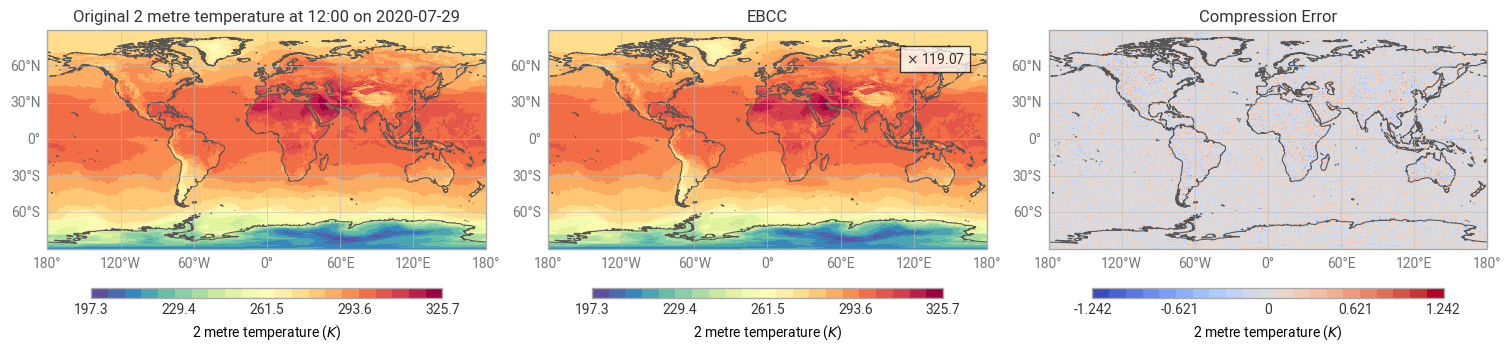

In [15]:
# plot a comparison figure
fig = earthkit.plots.Figure(
    figsize=(15, 4),
    rows=1,
    columns=3,
)

quickplot(da, fig.add_map(0, 0), title="Original {default_title}")
quickplot(
    da_dec,
    fig.add_map(0, 1),
    title="EBCC",
    cr=da.nbytes / np.array(da_enc).nbytes,
)
quickplot(da_dec - da, fig.add_map(0, 2), error=True, title="Compression Error")

fig.show()